<a href="https://colab.research.google.com/github/Khoawawa/DeepLearning-HCMUT-Exercise-MS/blob/main/Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
path = "/content/drive/MyDrive/DeepLearning/Exercise"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn

Phần 1

In [ ]:
class SoftmaxRegression(nn.Module):
  def __init__(self, C, H, W, num_class):
    # C, H, W
    super().__init__()
    self.head = nn.Linear(C * H * W, num_class)
  def forward(self, x):
    # x: [B,C,H,W]
    B, C, H, W = x.shape
    x_flatten = x.view(B, C * H * W) # [B,CHW]
    logits = self.head(x_flatten) # [B,CHW] * [CHW,num_class]
    return logits

In [ ]:
class MLP(nn.Module):
  def __init__(self, in_dim, hidden_dim, num_class, num_hidden_layer):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Linear(in_dim, hidden_dim),
        nn.ReLU(),
    )
    for _ in range(num_hidden_layer):
      self.mlp.append(nn.Linear(hidden_dim, hidden_dim))
      self.mlp.append(nn.ReLU())
    self.mlp.append(nn.Linear(hidden_dim, num_class))
  def forward(self, x):
    return self.mlp(x)

In [ ]:
class MLP_for_image(nn.Module):
  def __init__(self, C, H, W, hidden_dim, num_class, num_hidden_layer):
    super().__init__()
    self.mlp = MLP(C*H*W,hidden_dim,num_class,num_hidden_layer)
  def forward(self, x):
    x = x.view(x.size(0), -1)
    return self.mlp(x)

In [ ]:
class CNN(nn.Module):
  def __init__(self, C, H, W, hidden_dim, num_class,kernel_size=3, padding=1):
    super().__init__()
    self.cnn_block = nn.Sequential(
        nn.Conv2d(C,hidden_dim, kernel_size=kernel_size, padding = padding),
        nn.BatchNorm2d(hidden_dim),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(hidden_dim,hidden_dim * 2, kernel_size=kernel_size, padding = 1),
        nn.BatchNorm2d(hidden_dim * 2),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )
    self.head = SoftmaxRegression(hidden_dim * 2, H//4, W//4, num_class)
  def forward(self, x):
    # x: [B,C,H,W]
    # after first conv: [B,hidden,H,W]
    # after pooling: [B,hidden,H//2,W//2]
    # after second conv: [B,hidden * 2, H//2, W//2]
    # after pooling: [B,hidden * 2, H//4, W//4]
    x = self.cnn_block(x)
    logits = self.head(x)
    return logits

In [ ]:
class ViT(nn.Module):
  def __init__(self,num_class,P, C, H, W, hidden_dim, num_head, transformer_num_layer, mlp_num_layer):
    super().__init__()
    # image patching --> embedding --> PE --> MHA --> MLP
    assert H % P == 0 and W % P == 0
    self.P = P
    self.patch_embedding = nn.Linear(P*P*C, hidden_dim)
    self.num_patches = (H * W) // (P * P)
    self.pos_embedding = nn.Parameter(
        torch.randn(1, self.num_patches + 1, hidden_dim)
    )
    self.cls_token = nn.Parameter(
        torch.randn(1, 1, hidden_dim)
    )
    transformer_layer = nn.TransformerEncoderLayer(
        d_model = hidden_dim,
        nhead = num_head,
        dim_feedforward = 4 * hidden_dim,
        batch_first = True,
        norm_first = True # prenorm
    )
    self.transformer = nn.TransformerEncoder(
        encoder_layer = transformer_layer,
        num_layers = transformer_num_layer
    )
    self.head = MLP(hidden_dim,hidden_dim,num_class,mlp_num_layer)

  def patch_image(self,x):
    # x: [B,C,H,W]
    B, C, _, _ = x.shape
    P = self.P

    x = x.unfold(2, P, P) # [B,C,H/P,W,P]
    x = x.unfold(3, P, P) # [B,C,H/P,W/P,P,P]
    x = x.permute(0, 2, 3, 4, 5, 1) # [B,H/P,W/P,P,P, C]
    x = x.reshape(B, self.num_patches, P * P * C) # [B,num_patch, P*P*C]
    return x
  def forward(self, x):
    # x: [B,C,H,W]
    B, _, _, _ = x.shape

    x_patch = self.patch_image(x) # [B,num_patch, P*P*C]

    x_emb = self.patch_embedding(x_patch) # [B,num_patch, hidden_dim]
    # adding cls token
    cls_token = self.cls_token.expand(B, -1, -1)
    x_emb = torch.cat([cls_token, x_emb], dim = 1) # [B, 1 + num_patch, hidden_dim]
    #PE
    x_emb = x_emb + self.pos_embedding # [B,1 + num_patch, hidden_dim]

    x_emb = self.transformer(x_emb) # [B, 1 + num_patch, hidden_dim]

    logits = self.head(x_emb[:,0,:]) # [B, hidden_dim]

    return logits


PHẦN 2

In [ ]:
from tqdm import tqdm
import copy
import time

In [ ]:
def train(model,train_loader, val_loader, optimizer, criterion,device,num_epoch, patience=3):
  model.to(device)

  history = {
      "train_loss": [],
      "train_acc": [],
      "val_loss": [],
      "val_acc": [],
      "epoch_time": [],
      "avg_epoch_time": None
  }

  best_val_acc = float("-inf")
  patience_c = 0
  best_state = None

  for epoch in range(num_epoch):
    start_time = time.perf_counter()
    model.train()
    # train loop

    train_loss = 0
    correct = 0
    total = 0
    for batch, label in tqdm(train_loader):
      batch = batch.to(device)
      label = label.to(device)

      logits = model(batch)
      loss = criterion(logits, label)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_loss += loss.item()

      pred = torch.argmax(logits, dim=1)
      correct += (pred == label).sum().item()
      total += label.size(0)

    train_acc = correct / total
    train_loss /= len(train_loader)

    # val loop
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
      for batch, label in tqdm(val_loader):

        batch = batch.to(device)
        label = label.to(device)

        logits = model(batch)
        loss = criterion(logits, label)

        val_loss += loss.item()

        pred = torch.argmax(logits, dim=1)
        correct += (pred == label).sum().item()
        total += label.size(0)

    val_acc = correct / total
    val_loss /= len(val_loader)

    epoch_time = time.perf_counter() - start_time
    history["epoch_time"].append(epoch_time)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: val_acc = {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      patience_c = 0
      best_state = copy.deepcopy(model.state_dict())
    else:
      patience_c += 1

      if patience_c >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        model.load_state_dict(best_state)
        break
  history["avg_epoch_time"] = sum(history["epoch_time"]) / len(history["epoch_time"])

  return model, history


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def eval(model, test_loader,device):

  model.to(device)
  model.eval()
  correct = 0
  total = 0

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for batch, label in tqdm(test_loader):
      batch = batch.to(device)

      logits = model(batch)
      pred = torch.argmax(logits, dim=1).cpu()

      all_preds.extend(pred.numpy())
      all_labels.extend(label.numpy())

  cm = confusion_matrix(all_labels, all_preds)
  acc = accuracy_score(all_labels, all_preds)
  precision = precision_score(all_labels, all_preds, average="macro")
  recall = recall_score(all_labels, all_preds, average="macro")
  f1 = f1_score(all_labels, all_preds, average="macro")

  return {
      "cm": cm,
      "acc": acc,
      "precision": precision,
      "recall": recall,
      "f1": f1
  }

In [ ]:
def pipeline(model,loaders,optimizer,criterion, n_train_epoch,device,patience=3):
  train_loader, val_loader, test_loader = loaders
  model, history = train(model,train_loader, val_loader, optimizer, criterion,device,n_train_epoch,patience)
  eval_result = eval(model, test_loader,device)
  return model, history, eval_result

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

def load_loader(dataset_name, batch_size=64, val_ratio=0.1):
    dataset_name = dataset_name.lower()
    root = "/content/data"

    if dataset_name == "mnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        Dataset = torchvision.datasets.MNIST
        C, H, W = 1, 28, 28

    elif dataset_name == "fashionmnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        Dataset = torchvision.datasets.FashionMNIST
        C, H, W = 1, 28, 28

    elif dataset_name == "cifar10":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        ])
        Dataset = torchvision.datasets.CIFAR10
        C, H, W = 3, 32, 32

    else:
        raise ValueError("dataset_name must be: mnist, fashionmnist, or cifar10")

    full_train_dataset = Dataset(root=root, train=True, download=True, transform=transform)
    test_dataset = Dataset(root=root, train=False, download=True, transform=transform)

    val_size = int(len(full_train_dataset) * val_ratio)
    train_size = len(full_train_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    class_names = full_train_dataset.classes
    idx_to_class = {i: cls_name for i, cls_name in enumerate(class_names)}

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, (C, H, W), idx_to_class

In [ ]:
def save_result_to_drive(path,model_dict,best_models,histories,eval_results):
  os.makedirs(path, exist_ok=True)

  for model_name in model_dict.keys():
    model_path = os.path.join(path, model_name)
    os.makedirs(f"{path}/{model_name}", exist_ok=True)

    torch.save({
            "model_state_dict": best_models[model_name].state_dict(),
            "model_config": str(model_dict[model_name]),
        }, os.path.join(model_path, "best_model.pth"))

    with open(f"{model_path}/history.txt", "w") as f:
      f.write(str(histories[model_name]))

    with open(f"{model_path}/eval_result.txt", "w") as f:
      f.write(str(eval_results[model_name]))

In [ ]:
def compare_models(model_dicts, loaders,n_train_epoch,device,patience, save_path):
  best_models, histories, eval_results = {}, {}, {}
  for model_name, model in model_dicts.items():
    print(f"Model: {model_name}")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_model, history,eval_result = pipeline(model,loaders,optimizer, criterion, n_train_epoch,device,patience)

    best_models[model_name] = best_model
    histories[model_name] = history
    eval_results[model_name] = eval_result

  save_result_to_drive(save_path,model_dicts,best_models,histories,eval_results)

  return best_models, histories, eval_results

In [ ]:
dataset_name = "cifar10"
batch_size = 64
hidden_dim = 128
val_ratio = 0.1
mlp_hidden_layer = 1
kernel_size, padding = 3, 1 # preserve dim before pooling
P = 4
vit_head = 4
transformer_layer = 2

rnn_layer = 2

lr = 1e-3
n_train_epoch = 10
patience = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
train_loader, val_loader, test_loader, (C,H,W), idx_to_class = load_loader(dataset_name,batch_size,val_ratio)
loaders = (train_loader, val_loader, test_loader)
num_class = len(idx_to_class)


model_dict = {
    "softmax": SoftmaxRegression(C,H,W, num_class),
    "mlp": MLP_for_image(C,H,W,hidden_dim,num_class, mlp_hidden_layer),
    "cnn": CNN(C,H,W,hidden_dim,num_class),
    "vit": ViT(num_class,P,C,H,W,hidden_dim,vit_head,transformer_layer,mlp_hidden_layer)
}

100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]
/tmp/ipykernel_6326/1348582425.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [ ]:
best_models, histories, eval_results = {}, {}, {}
for model_name, model in model_dict.items():
  print(f"Model: {model_name}")
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()
  best_model, history,eval_result = pipeline(model,loaders,optimizer, criterion, n_train_epoch,device,patience)

  best_models[model_name] = best_model
  histories[model_name] = history
  eval_results[model_name] = eval_result

Model: softmax


100%|██████████| 79/79 [00:01<00:00, 68.99it/s]


Epoch 1: val_acc = 0.3680


100%|██████████| 79/79 [00:01<00:00, 67.11it/s]


Epoch 2: val_acc = 0.3652


...

100%|██████████| 79/79 [00:01<00:00, 60.63it/s]


Epoch 9: val_acc = 0.5598


100%|██████████| 79/79 [00:01<00:00, 61.07it/s]


Epoch 10: val_acc = 0.5612


100%|██████████| 157/157 [00:02<00:00, 62.35it/s]


In [ ]:
save_result_to_drive(path,model_dict,best_models,histories,eval_results)

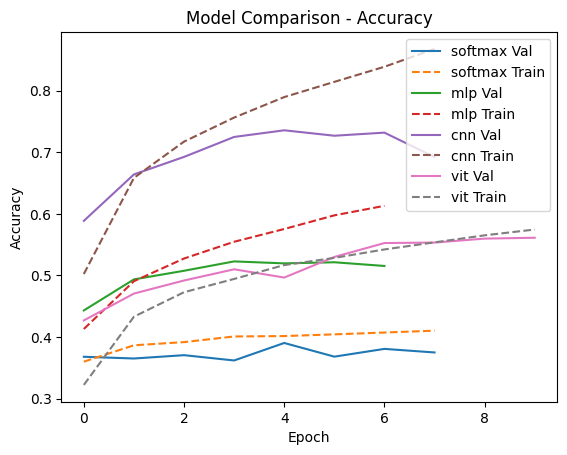

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{model_name} Val")
    plt.plot(history["train_acc"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.legend()
plt.savefig("compare_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

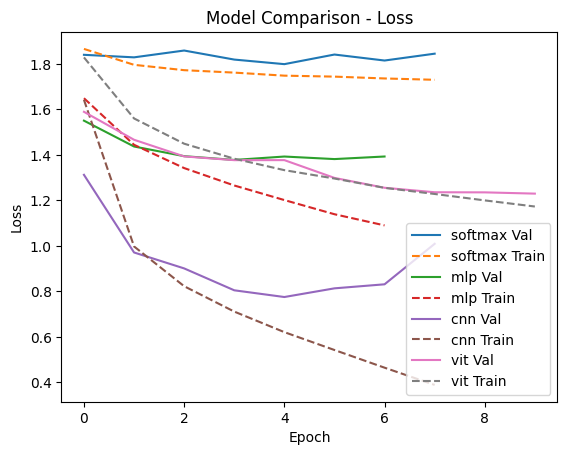

In [ ]:
plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_loss"], label=f"{model_name} Val")
    plt.plot(history["train_loss"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Comparison - Loss")
plt.legend()
plt.savefig("compare_loss.png", dpi=300, bbox_inches="tight")
plt.show()


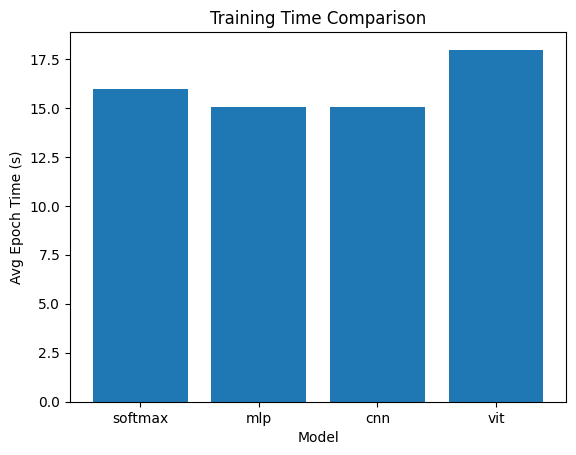

In [ ]:
plt.figure()

model_names = []
avg_times = []

for model_name, history in histories.items():
    model_names.append(model_name)
    avg_times.append(history["avg_epoch_time"])

plt.bar(model_names, avg_times)
plt.xlabel("Model")
plt.ylabel("Avg Epoch Time (s)")
plt.title("Training Time Comparison")
plt.savefig("compare_time.png", dpi=300, bbox_inches="tight")
plt.show()

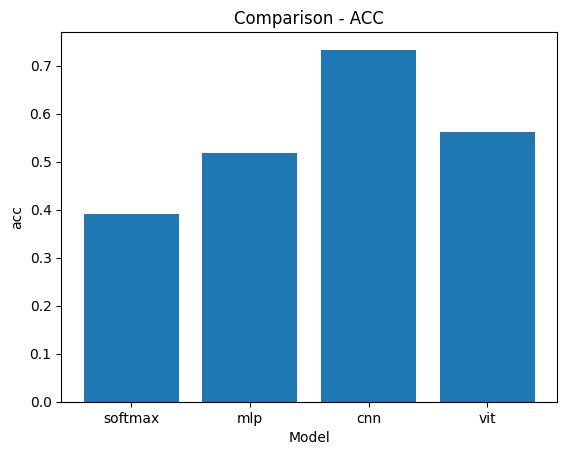

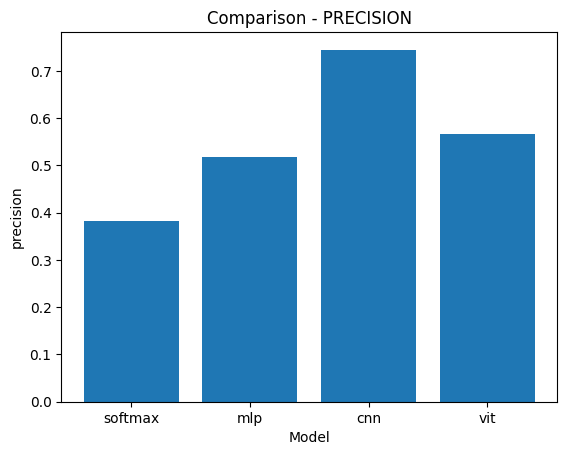

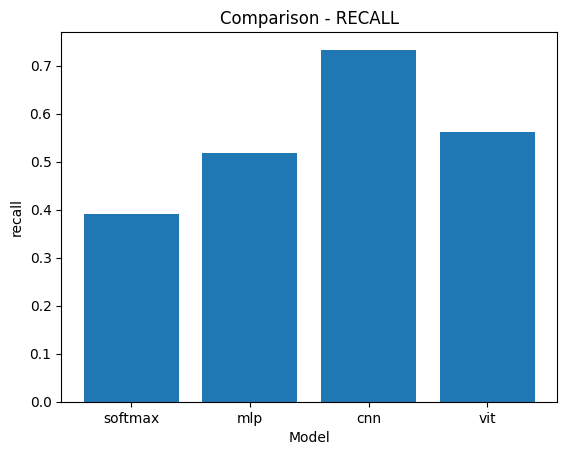

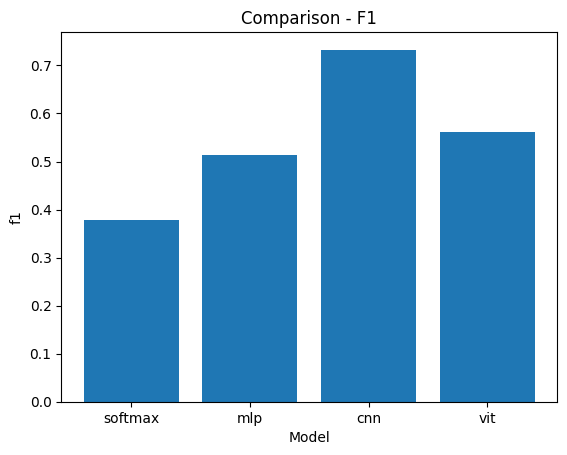

In [ ]:
metrics = ["acc", "precision", "recall", "f1"]

for metric in metrics:
    plt.figure()

    names = []
    values = []

    for model_name, result in eval_results.items():
        names.append(model_name)
        values.append(result[metric])

    plt.bar(names, values)
    plt.title(f"Comparison - {metric.upper()}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.savefig(f"compare_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

PHẦN 3

In [ ]:
import math

In [ ]:
class MultiHeadSelfAttention(nn.Module):
  def __init__(self, d_model, num_head):
    super().__init__()
    assert d_model % num_head == 0
    self.d_model = d_model
    self.num_head = num_head
    self.head_dim = d_model // num_head

    self.q = nn.Linear(d_model, d_model)
    self.k = nn.Linear(d_model, d_model)
    self.v = nn.Linear(d_model, d_model)

    self.out = nn.Linear(d_model, d_model)

  def split_heads(self, x):
    B, L,_ = x.shape
    x = x.reshape(B, L, self.num_head, self.head_dim) # [B,L,H,D//H]
    x = x.permute(0, 2, 1, 3) # [B,H,L,D//H]
    return x

  def forward(self, x):
    # x: [B,L, hidden_dim]

    Q = self.split_heads(self.q(x))
    K = self.split_heads(self.k(x))
    V = self.split_heads(self.v(x))

    # scaled Dot-product Attention
    scores = torch.matmul(Q, K.transpose(-1,-2)) / math.sqrt(self.head_dim) # [B,H,L,L]

    weights = torch.softmax(scores, dim=-1) # [B,H,L,L]

    attention = torch.matmul(weights, V) # [B,H,L,D//H]
    # concat
    B, H, L, _ = attention.shape
    attention = attention.permute(0, 2, 1, 3) # [B,L,H,D//H]

    attention = attention.reshape(B, L, self.d_model) # [B,L,D]

    out = self.out(attention) # [B,L,D]

    return out

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(self,d_model,nhead,dim_ff,dropout=0.1,layernorm_eps=1e-05):
    super().__init__()
    self.pre_norm = nn.LayerNorm(d_model, eps=layernorm_eps)

    self.self_attention = MultiHeadSelfAttention(d_model, nhead)

    self.after_norm = nn.LayerNorm(d_model, eps=layernorm_eps)
    self.feed_forward = nn.Sequential(
        nn.Linear(d_model, dim_ff),
        nn.GELU(),
        nn.Linear(dim_ff, d_model)
    )
    self.dropout = nn.Dropout(dropout)
  def forward(self, x):
    # [B, L, D]
    x_norm = self.pre_norm(x)
    x_attn = self.self_attention(x_norm)
    x = x + self.dropout(x_attn)
    x_norm = self.after_norm(x)
    x_ff = self.feed_forward(x_norm)

    return x + self.dropout(x_ff)

In [ ]:
class TransformerEncoder(nn.Module):
  def __init__(self,encoder_layer, num_layers):
    super().__init__()
    self.encoder_stack = nn.ModuleList(
        [copy.deepcopy(encoder_layer) for _ in range(num_layers)]
        )
  def forward(self, x):
    for layer in self.encoder_stack:
      x = layer(x)
    return x

In [ ]:
class ViT_i(nn.Module):
  def __init__(self,num_class,P, C, H, W, hidden_dim, num_head, transformer_num_layer, mlp_num_layer):
    super().__init__()
    # image patching --> embedding --> PE --> MHA --> MLP
    assert H % P == 0 and W % P == 0
    self.P = P
    self.patch_embedding = nn.Linear(P*P*C, hidden_dim)
    self.num_patches = (H * W) // (P * P)
    self.pos_embedding = nn.Parameter(
        torch.randn(1, self.num_patches + 1, hidden_dim)
    )
    self.cls_token = nn.Parameter(
        torch.randn(1, 1, hidden_dim)
    )
    transformer_layer = TransformerEncoderLayer(
        d_model = hidden_dim,
        nhead = num_head,
        dim_ff = 4 * hidden_dim,
    )
    self.transformer = TransformerEncoder(
        encoder_layer = transformer_layer,
        num_layers = transformer_num_layer
    )
    self.head = MLP(hidden_dim,hidden_dim,num_class,mlp_num_layer)

  def patch_image(self,x):
    # x: [B,C,H,W]
    B, C, _, _ = x.shape
    P = self.P

    x = x.unfold(2, P, P) # [B,C,H/P,W,P]
    x = x.unfold(3, P, P) # [B,C,H/P,W/P,P,P]
    x = x.permute(0, 2, 3, 4, 5, 1) # [B,H/P,W/P,P,P, C]
    x = x.reshape(B, self.num_patches, P * P * C) # [B,num_patch, P*P*C]
    return x
  def forward(self, x):
    # x: [B,C,H,W]
    B, _, _, _ = x.shape

    x_patch = self.patch_image(x) # [B,num_patch, P*P*C]

    x_emb = self.patch_embedding(x_patch) # [B,num_patch, hidden_dim]
    # adding cls token
    cls_token = self.cls_token.expand(B, -1, -1)
    x_emb = torch.cat([cls_token, x_emb], dim = 1) # [B, 1 + num_patch, hidden_dim]
    #PE
    x_emb = x_emb + self.pos_embedding # [B,1 + num_patch, hidden_dim]

    x_emb = self.transformer(x_emb) # [B, 1 + num_patch, hidden_dim]

    logits = self.head(x_emb[:,0,:]) # [B, hidden_dim]

    return logits


In [ ]:
part_3_model_dict = {
    "ViT_implement" : ViT_i(num_class,P,C,H,W,hidden_dim,vit_head,transformer_layer,mlp_hidden_layer),
    "ViT": ViT(num_class,P,C,H,W,hidden_dim,vit_head,transformer_layer,mlp_hidden_layer)
}

/tmp/ipykernel_6326/1348582425.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [ ]:
path = '/content'

In [ ]:
part_3_path = path + "/part3"

NameError: name 'path' is not defined

In [ ]:
best_models, histories, eval_results = {}, {}, {}
for model_name, model in part_3_model_dict.items():
  print(f"Model: {model_name}")
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()
  best_model, history,eval_result = pipeline(model,loaders,optimizer, criterion, n_train_epoch,device,patience)

  best_models[model_name] = best_model
  histories[model_name] = history
  eval_results[model_name] = eval_result

Model: ViT_implement


100%|██████████| 79/79 [00:01<00:00, 61.68it/s]


Epoch 1: val_acc = 0.4172


100%|██████████| 79/79 [00:01<00:00, 59.08it/s]


Epoch 2: val_acc = 0.4664


...

100%|██████████| 79/79 [00:01<00:00, 60.72it/s]


Epoch 9: val_acc = 0.5688


100%|██████████| 79/79 [00:01<00:00, 41.93it/s]


Epoch 10: val_acc = 0.5774


100%|██████████| 157/157 [00:02<00:00, 64.03it/s]


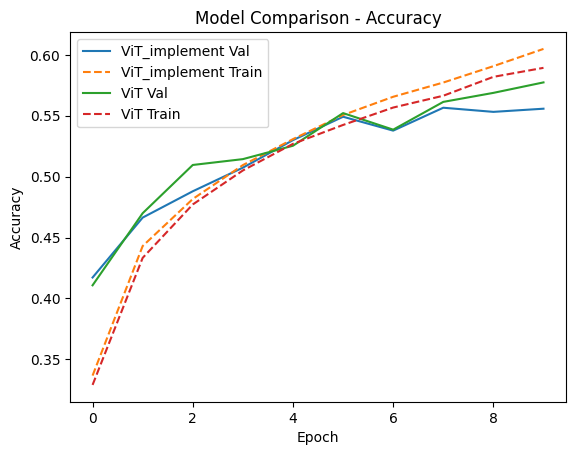

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{model_name} Val")
    plt.plot(history["train_acc"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.legend()
plt.savefig("compare_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

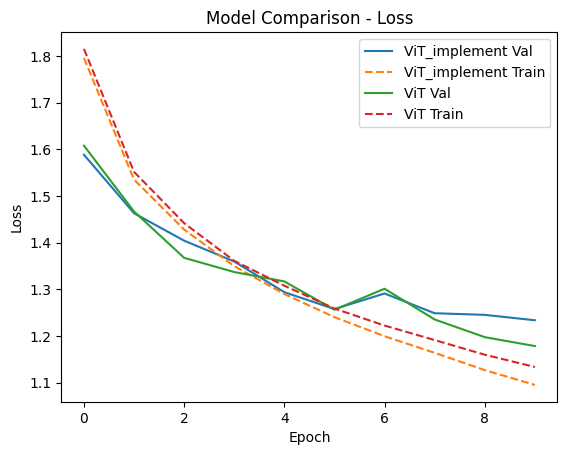

In [ ]:
plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_loss"], label=f"{model_name} Val")
    plt.plot(history["train_loss"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Comparison - Loss")
plt.legend()
plt.savefig("compare_loss.png", dpi=300, bbox_inches="tight")
plt.show()

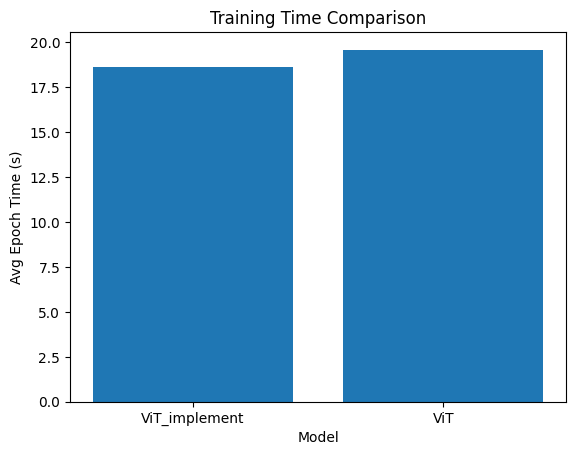

In [ ]:
plt.figure()

model_names = []
avg_times = []

for model_name, history in histories.items():
    model_names.append(model_name)
    avg_times.append(history["avg_epoch_time"])

plt.bar(model_names, avg_times)
plt.xlabel("Model")
plt.ylabel("Avg Epoch Time (s)")
plt.title("Training Time Comparison")
plt.savefig("compare_time.png", dpi=300, bbox_inches="tight")
plt.show()

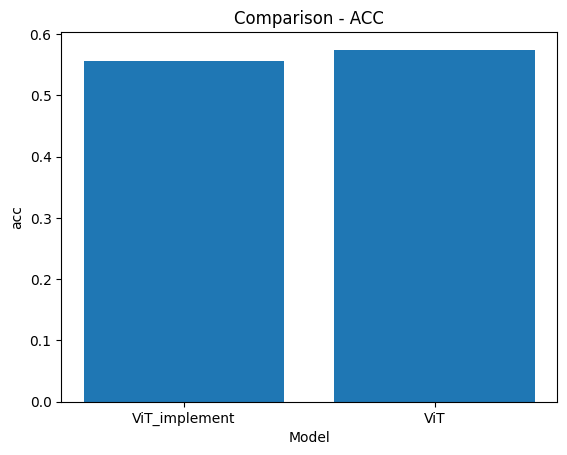

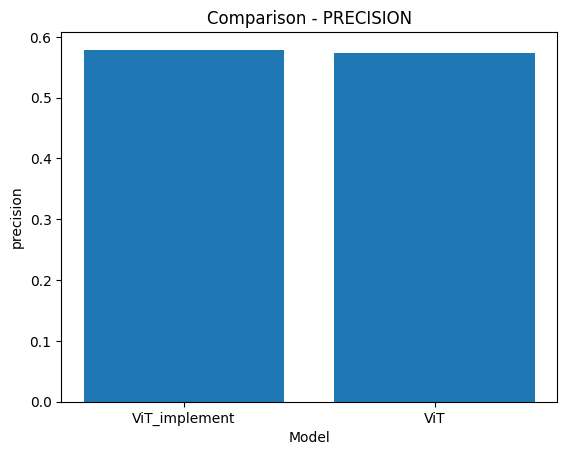

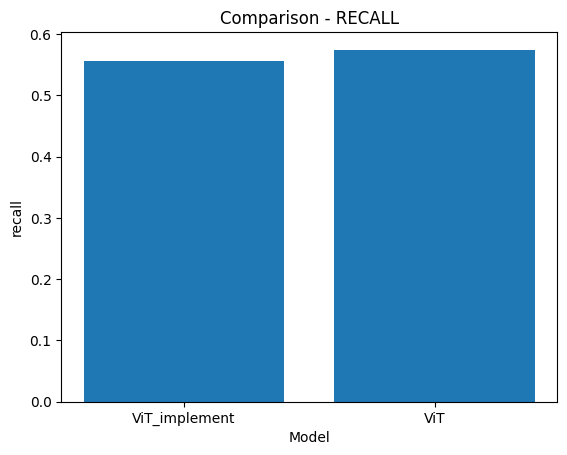

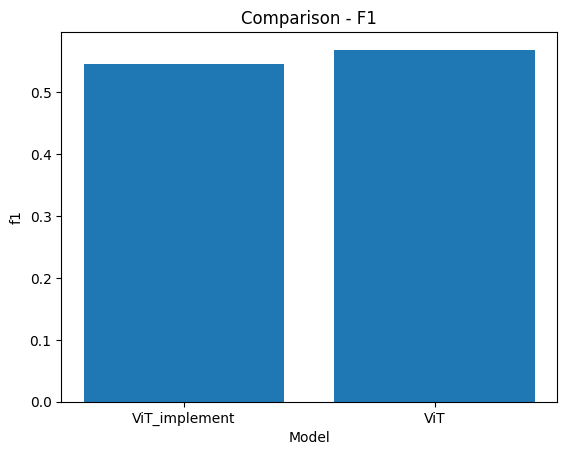

In [ ]:
metrics = ["acc", "precision", "recall", "f1"]

for metric in metrics:
    plt.figure()

    names = []
    values = []

    for model_name, result in eval_results.items():
        names.append(model_name)
        values.append(result[metric])

    plt.bar(names, values)
    plt.title(f"Comparison - {metric.upper()}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.savefig(f"compare_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

PHẦN 4

In [ ]:
class CNNFormer(nn.Module):
  def __init__(self,C,H,W,hidden_dim,num_class,P,nhead,transformer_layer,classifier_hidden_layer,sequential_strategy,kernel_size=3,padding=1):
    super().__init__()
    self.sequential_strategy = sequential_strategy
    self.cnn = nn.Sequential(
        nn.Conv2d(C,hidden_dim, kernel_size=kernel_size, padding = padding), # kernel size = 3 and padding 1 to preserve dimension
        nn.BatchNorm2d(hidden_dim),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(hidden_dim,hidden_dim * 2, kernel_size=kernel_size, padding = 1),
        nn.BatchNorm2d(hidden_dim * 2),
        nn.ReLU(),
        nn.MaxPool2d(2)
    ) #[B,hidden * 2, H//4, W//4]
    H_ = H // 4
    W_ = W // 4
    C_ = hidden_dim * 2
    if sequential_strategy == "vectorize_HW":
      in_dim = C_
    elif sequential_strategy == "vectorize_C":
      in_dim = H_ * W_
    elif sequential_strategy == "vectorize_H":
      in_dim = C_ * W_
    elif sequential_strategy == "vectorize_W":
      in_dim = C_ * H_
    else:
      raise ValueError("Invalid sequential strategy")

    self.proj = nn.Linear(in_dim, hidden_dim * 2)

    if sequential_strategy == "vectorize_HW":
      num_tokens = H_ * W_
    elif sequential_strategy == "vectorize_C":
      num_tokens = C_
    elif sequential_strategy == "vectorize_H":
      num_tokens = H_
    elif sequential_strategy == "vectorize_W":
      num_tokens = W_

    self.learnable_pos = nn.Parameter(
        torch.randn(1, num_tokens + 1, hidden_dim * 2)
    )

    self.cls_token = nn.Parameter(
        torch.randn(1, 1, hidden_dim * 2)
    )

    encoder_layer = nn.TransformerEncoderLayer(hidden_dim*2,nhead,hidden_dim*8,batch_first=True,norm_first=True)

    self.transformer = nn.TransformerEncoder(encoder_layer,transformer_layer)

    self.head = MLP(hidden_dim*2,hidden_dim*2,num_class,classifier_hidden_layer)

  def sequentialize_image(self, x):
    # x: [B,C,H,W]
    if self.sequential_strategy == "vectorize_HW":
      return x.reshape(x.size(0), x.size(1), -1).permute(0, 2, 1) # [B,L,D] --> L = H*W, D = C
    elif self.sequential_strategy == "vectorize_C":
      return x.reshape(x.size(0), x.size(1), -1) # [B,L,D] --> L = C, D = H*W
    elif self.sequential_strategy == "vectorize_H":
      return x.permute(0, 2, 1, 3).reshape(x.size(0), x.size(2), -1) # [B,L,D] --> L = H, D = C*W
    elif self.sequential_strategy == "vectorize_W":
      return x.permute(0, 3, 1, 2).reshape(x.size(0), x.size(3), -1) # [B,L,D] --> L = W, D = C*H
    else:
      raise ValueError("Invalid sequential strategy")
  def forward(self, x):
    x = self.cnn(x) # [B,hidden * 2, H//4, W//4]
    x_token = self.proj(self.sequentialize_image(x)) # [B,L,D]
    # preprend cls token
    B, L, _ = x_token.shape
    cls_token = self.cls_token.expand(B, -1, -1)
    x_token = torch.cat([cls_token, x_token], dim=1)

    x_token = x_token + self.learnable_pos

    attention = self.transformer(x_token) # [B,L,D]
    logits = self.head(attention[:,0,:]) # [B,D]

    return logits


In [ ]:
model_dicts = {
    "CNNFormer_hw" : CNNFormer(C,H,W,hidden_dim,num_class,P,vit_head,transformer_layer,mlp_hidden_layer,"vectorize_HW",kernel_size,padding),
    "CNNFormer_c" : CNNFormer(C,H,W,hidden_dim,num_class,P,vit_head,transformer_layer,mlp_hidden_layer,"vectorize_C",kernel_size,padding),
    "CNNFormer_h" : CNNFormer(C,H,W,hidden_dim,num_class,P,vit_head,transformer_layer,mlp_hidden_layer,"vectorize_H",kernel_size,padding),
    "CNNFormer_w" : CNNFormer(C,H,W,hidden_dim,num_class,P,vit_head,transformer_layer,mlp_hidden_layer,"vectorize_W",kernel_size,padding),
}

/tmp/ipykernel_6326/2242538866.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer,transformer_layer)


In [ ]:
best_models, histories, eval_results = {}, {}, {}
for model_name, model in model_dicts.items():
  print(f"Model: {model_name}")
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()
  best_model, history,eval_result = pipeline(model,loaders,optimizer, criterion, n_train_epoch,device,patience)

  best_models[model_name] = best_model
  histories[model_name] = history
  eval_results[model_name] = eval_result

Model: CNNFormer_hw


100%|██████████| 79/79 [00:01<00:00, 56.09it/s]


Epoch 1: val_acc = 0.5102


100%|██████████| 79/79 [00:01<00:00, 57.58it/s]


Epoch 2: val_acc = 0.5916


...

100%|██████████| 79/79 [00:01<00:00, 58.11it/s]


Epoch 9: val_acc = 0.7626


100%|██████████| 79/79 [00:01<00:00, 42.90it/s]


Epoch 10: val_acc = 0.7632


100%|██████████| 157/157 [00:02<00:00, 59.53it/s]


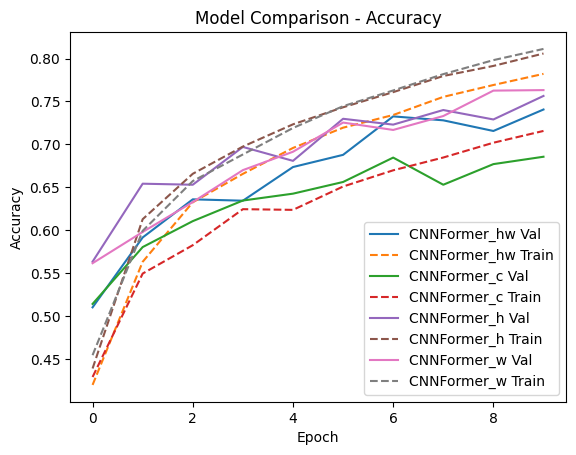

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{model_name} Val")
    plt.plot(history["train_acc"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.legend()
plt.savefig("compare_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

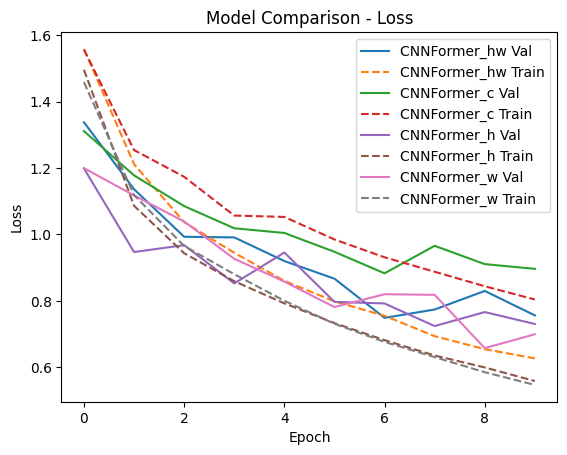

In [ ]:
plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_loss"], label=f"{model_name} Val")
    plt.plot(history["train_loss"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Comparison - Loss")
plt.legend()
plt.savefig("compare_loss.png", dpi=300, bbox_inches="tight")
plt.show()

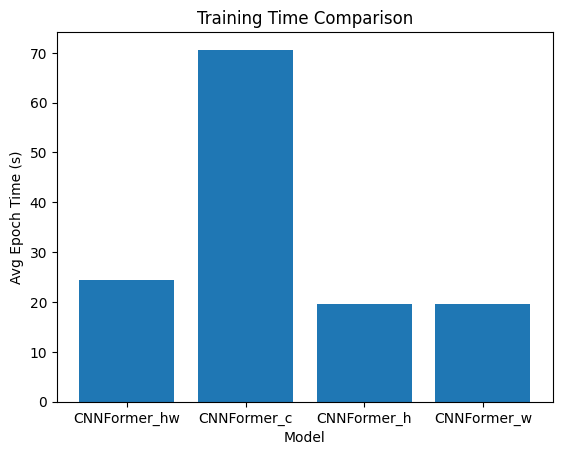

In [ ]:
plt.figure()

model_names = []
avg_times = []

for model_name, history in histories.items():
    model_names.append(model_name)
    avg_times.append(history["avg_epoch_time"])

plt.bar(model_names, avg_times)
plt.xlabel("Model")
plt.ylabel("Avg Epoch Time (s)")
plt.title("Training Time Comparison")
plt.savefig("compare_time.png", dpi=300, bbox_inches="tight")
plt.show()

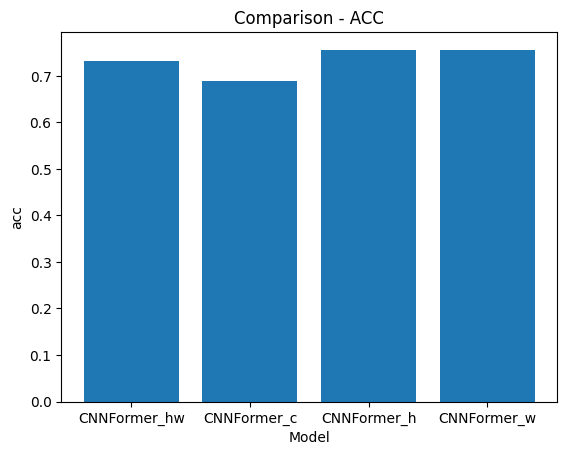

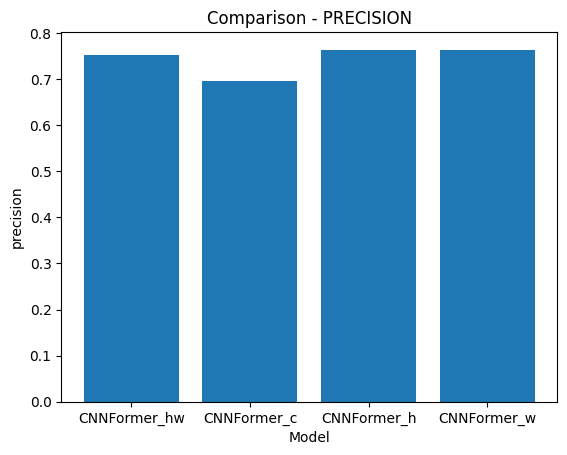

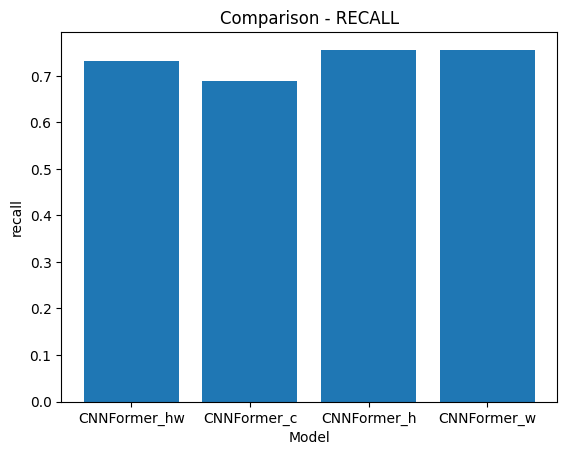

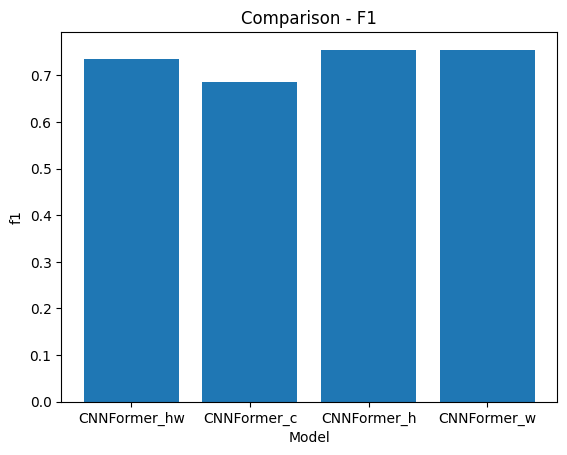

In [ ]:
metrics = ["acc", "precision", "recall", "f1"]

for metric in metrics:
    plt.figure()

    names = []
    values = []

    for model_name, result in eval_results.items():
        names.append(model_name)
        values.append(result[metric])

    plt.bar(names, values)
    plt.title(f"Comparison - {metric.upper()}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.savefig(f"compare_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

PHẦN 5

In [ ]:
class IGRU(nn.Module):
  def __init__(self, C, H, W, hidden_dim, num_class,num_layer,classifier_layer):
    super().__init__()

    self.lstm = nn.GRU(
        input_size=C*W,
        hidden_size=hidden_dim,
        num_layers=num_layer,
        batch_first=True,
        )
    self.head = MLP(hidden_dim, hidden_dim,num_class,classifier_layer)
  def sequentialize_image(self, x):
    # x : [B,C,H,W]
    B,C,H,W = x.shape
    x = x.permute(0,2,1,3)
    x = x.reshape(B,H,C*W)
    return x
  def forward(self, x):
    x_seq = self.sequentialize_image(x) # [B,L,D]

    _, final_hidden_state = self.lstm(x_seq) # [num_layer,B,D]

    h_last = final_hidden_state[-1] #[B,hidden_dim]

    logits = self.head(h_last)

    return logits

In [ ]:
class ILSTM(nn.Module):
  def __init__(self, C, H, W, hidden_dim, num_class,num_layer,classifier_layer):
    super().__init__()

    self.lstm = nn.LSTM(
        input_size=C*W,
        hidden_size=hidden_dim,
        num_layers=num_layer,
        batch_first=True,
        )
    self.head = MLP(hidden_dim, hidden_dim,num_class,classifier_layer)
  def sequentialize_image(self, x):
    # x : [B,C,H,W]
    B,C,H,W = x.shape
    x = x.permute(0,2,1,3)
    x = x.reshape(B,H,C*W)
    return x
  def forward(self, x):
    x_seq = self.sequentialize_image(x) # [B,L,D]

    _, (final_hidden_state,_) = self.lstm(x_seq) # [num_layer,B,D]

    h_last = final_hidden_state[-1] #[B,hidden_dim]

    logits = self.head(h_last)

    return logits

In [ ]:
model_dicts = {
    "igru" : IGRU(C,H,W,hidden_dim,num_class,rnn_layer,mlp_hidden_layer),
    "ilstm" : ILSTM(C,H,W,hidden_dim,num_class,rnn_layer,mlp_hidden_layer)
}

In [ ]:
best_models, histories, eval_results = {}, {}, {}
for model_name, model in model_dicts.items():
  print(f"Model: {model_name}")
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()
  best_model, history,eval_result = pipeline(model,loaders,optimizer, criterion, n_train_epoch,device,patience)

  best_models[model_name] = best_model
  histories[model_name] = history
  eval_results[model_name] = eval_result

Model: igru


100%|██████████| 79/79 [00:01<00:00, 61.53it/s]


Epoch 1: val_acc = 0.4230


100%|██████████| 79/79 [00:01<00:00, 62.08it/s]


Epoch 2: val_acc = 0.4966


...

100%|██████████| 79/79 [00:01<00:00, 59.77it/s]


Epoch 9: val_acc = 0.5802


100%|██████████| 79/79 [00:01<00:00, 60.68it/s]


Epoch 10: val_acc = 0.5902


100%|██████████| 157/157 [00:02<00:00, 53.87it/s]


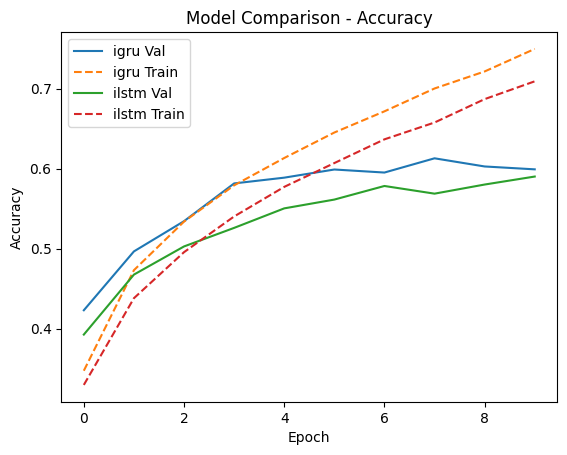

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_acc"], label=f"{model_name} Val")
    plt.plot(history["train_acc"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.legend()
plt.savefig("compare_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

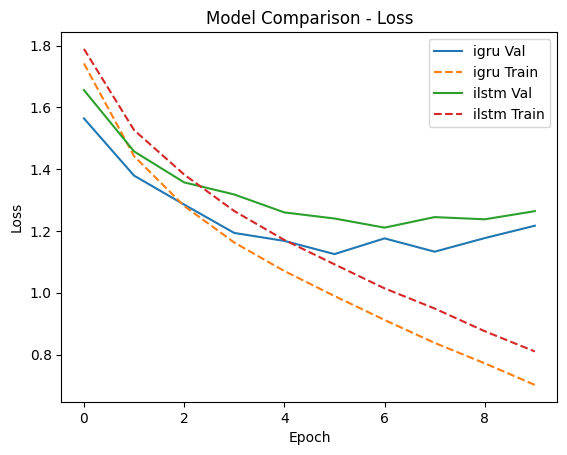

In [ ]:
plt.figure()
for model_name, history in histories.items():
    plt.plot(history["val_loss"], label=f"{model_name} Val")
    plt.plot(history["train_loss"], linestyle='--', label=f"{model_name} Train")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Comparison - Loss")
plt.legend()
plt.savefig("compare_loss.png", dpi=300, bbox_inches="tight")
plt.show()

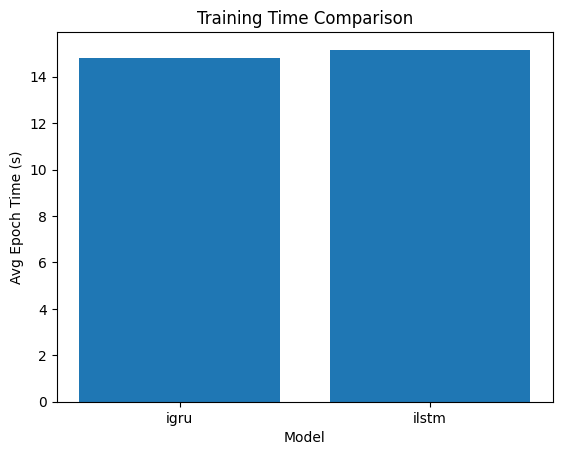

In [ ]:
plt.figure()

model_names = []
avg_times = []

for model_name, history in histories.items():
    model_names.append(model_name)
    avg_times.append(history["avg_epoch_time"])

plt.bar(model_names, avg_times)
plt.xlabel("Model")
plt.ylabel("Avg Epoch Time (s)")
plt.title("Training Time Comparison")
plt.savefig("compare_time.png", dpi=300, bbox_inches="tight")
plt.show()

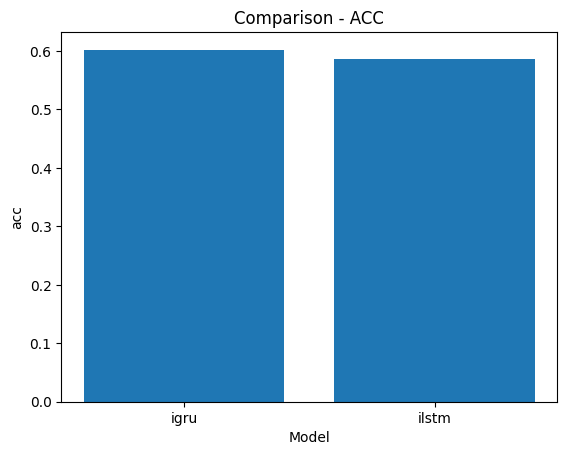

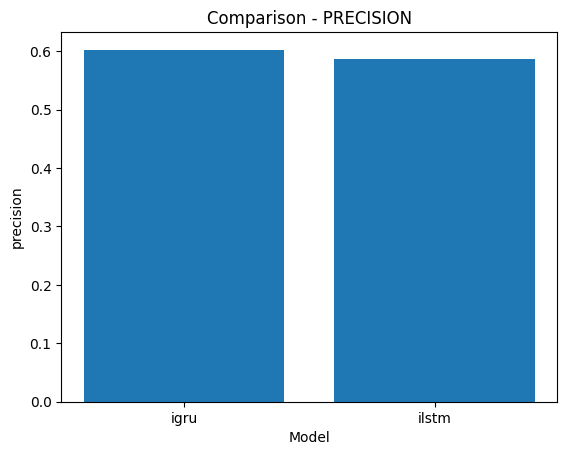

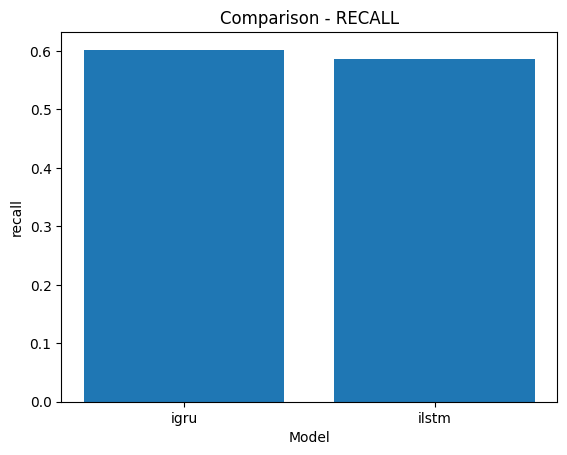

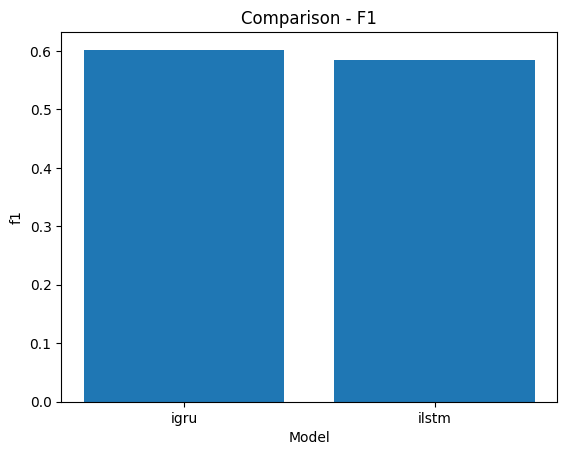

In [ ]:
metrics = ["acc", "precision", "recall", "f1"]

for metric in metrics:
    plt.figure()

    names = []
    values = []

    for model_name, result in eval_results.items():
        names.append(model_name)
        values.append(result[metric])

    plt.bar(names, values)
    plt.title(f"Comparison - {metric.upper()}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.savefig(f"compare_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()